# Graphicalizing Aesop's Fables

This notebook downloads the public-domain Project Gutenberg text for [Æsop's Fables #53103](https://www.gutenberg.org/ebooks/53103), splits it into tale-sized documents, and sends those documents through the ontology-guided semantic pipeline.

The notebook uses the package's default OpenAI `gpt-4.1-mini` client. Set `OPENAI_API_KEY` in the environment before running the model cell. The key is read by the OpenAI SDK and is never stored in this notebook.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from textwrap import wrap

from IPython.display import display

from semantic_graphicalizer import SemanticGraphicalizer, load_aesop_fables

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent

stories = load_aesop_fables(limit=1, cache_dir=ROOT / 'data' / 'raw', select_at_random=True, rand_seed=None)
[(story.splitlines()[0], len(story)) for story in stories]

[('THE CROW AND THE PITCHER', 589)]

## OpenAI model

The transformer creates the default `OpenAIModelClient` when `model` is omitted. It uses `gpt-4.1-mini` through the Responses API and reads `OPENAI_API_KEY` from the environment.

In [2]:
from textwrap import wrap

graphicalizer = SemanticGraphicalizer(
    ontology=ROOT / 'configs' / 'ontologies' / 'aesop.yaml',
    prompts=ROOT / 'configs' / 'prompts' / 'aesop.yaml',
)

graphicalizer.fit(stories)
traces = []

for index, story in enumerate(stories, start=1):
    trace = graphicalizer.transform_with_trace([story])[0]
    traces.append(trace)
    title = story.splitlines()[0]
    print(f"\nDocument {index}/{len(stories)}: {title}")
    print("\n".join(wrap(story, width=80)))
    print(f"ID: {trace.document_id}")
    print(f"Entities: {len(trace.entities)} | Relations: {len(trace.relations)} | "
          f"Nodes: {trace.graph.number_of_nodes()} | Edges: {trace.graph.number_of_edges()}")
    print("-" * 80)
    for relation in trace.relations:
        arguments = ", ".join(f"{argument.role}={argument.entity_id}" for argument in relation.arguments)
        print(f"- {relation.type}[{relation.relation}]({arguments})")
    print("\nGraph:")
    display(graphicalizer.display(trace.graph, mode="text"))
    print("=" * 80)


[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-a79cd0a84414] segment: 1 -> 1 | 0.1 ms | input_chars=589, chunk_chars=589
[document-a79cd0a84414 chunk-0] summarize: 1 -> 1 | 5388.4 ms
[document-a79cd0a84414 chunk-0] normalize: 1 -> 1 | 2047.2 ms
[document-a79cd0a84414 chunk-0] decompose: 1 -> 14 | 19443.7 ms
[document-a79cd0a84414 chunk-0] extract: 14 -> 30 | 24792.4 ms
[document-a79cd0a84414] resolve: 30 -> 0 | 756.9 ms
[document-a79cd0a84414] integrate: 14 -> 28 | 0.4 ms | nodes=29, edges=28
[document-a79cd0a84414] total: 1 -> 1 | 52429.7 ms | chunks=1, entities=15, relations=14, nodes=29, edges=28

Document 1/1: THE CROW AND THE PITCHER
THE CROW AND THE PITCHER   [Illustration: The Crow and The Pitcher]  A crow,
ready to die with thirst, flew with joy to a Pitcher, which he saw at a
distance. But when he came up to it, he found the water so low that with all his
stooping and straining he was unable to reach it. There

animal: crow
    has_trait: trait: extreme thirst
    wants: goal: quench its thirst
    located_in: place: a place where there is a pitcher containing water
    performs: action: try to drink the water by stooping and straining
    performs: action: fail to drink the water by stooping and straining
    performs: action: try to break and overturn the pitcher
    has_trait: trait: lacks the strength to break and overturn the pitcher
    performs: action: observes small pebbles nearby
    performs: action: casting pebbles one by one into the pitcher
    teaches: moral: using ingenuity and persistence to solve problems
place: a place where there is a pitcher containing water
    has_trait: trait: water level too low to reach
action: observes small pebbles nearby
    interacts_with: object: small pebbles
action: casting pebbles one by one into the pitcher
    [causal] causes: trait: water level rises to the brim
trait: water level rises to the brim
    [causal] causes: goal: quench its thi

In [3]:
graphicalizer.display(
    traces[0].graph,
    mode="dynamic",
    layout="force",
    show_source=True,
    max_width=34,
    width=1200,
    height=760,
    charge_strength=-10,
    link_distance=150,
    component_spacing=100,
    component_strength=0.3,
    parallel_edge_spacing=320
)

## Convert to AbstractGraph and visualize

The AbstractGraph adapter is optional. Install it with `pip install -e '.[abstractgraph]'` if it is not available in the current environment. This cell converts the extracted trace and renders its base and interpretation graphs with the AbstractGraph visualization helper.

<Axes: >

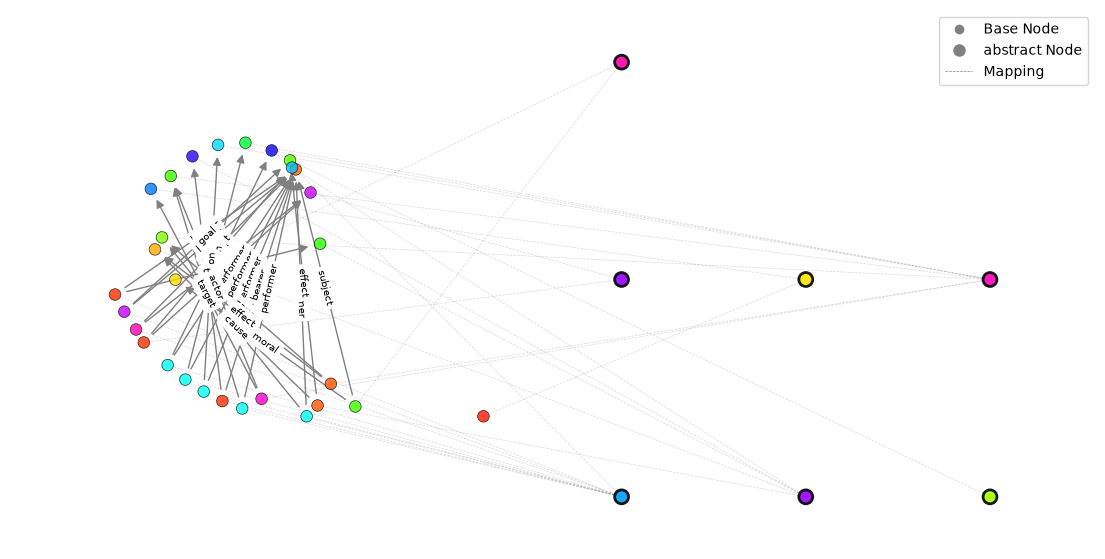

In [4]:
from abstractgraph import display as display_abstract_graph

abstract_graph = graphicalizer.to_abstract_graph(traces[0], embed_nodes=False)

display_abstract_graph(
    abstract_graph,
    size=(14, 7),
    show_legend=True,
    edge_labels=True,
    edge_label_attr="label",
    edge_label_font_size=7,
)